In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [57]:
df.shape

(1338, 7)

<Axes: xlabel='region', ylabel='charges'>

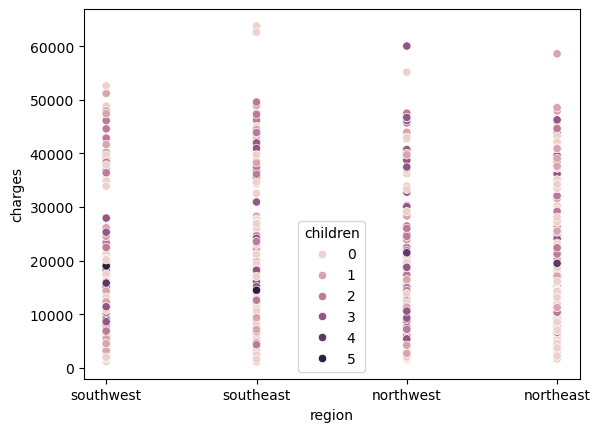

In [58]:
sns.scatterplot(data=df, x='region', y='charges',hue='children')

In [59]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [60]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [62]:
df['region'].sample(20)

513     southwest
374     southeast
134     northeast
935     southwest
739     southwest
1178    northeast
416     southeast
558     northwest
621     southwest
1124    northeast
938     southeast
588     northeast
243     southwest
756     northeast
802     southwest
372     northeast
349     northwest
522     northeast
691     southwest
992     southwest
Name: region, dtype: object

In [63]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

<Axes: ylabel='bmi'>

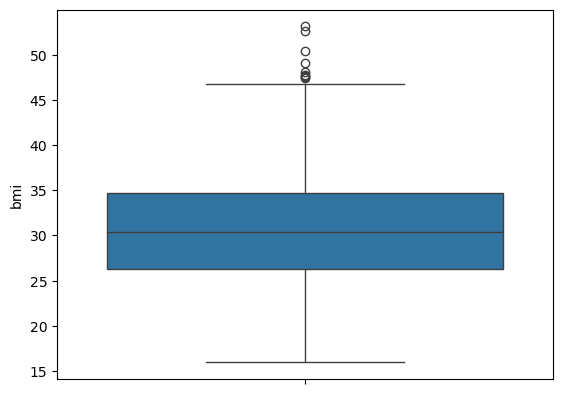

In [64]:
sns.boxplot(df['bmi'])

In [65]:
df['bmi'].min()

15.96

<Axes: ylabel='age'>

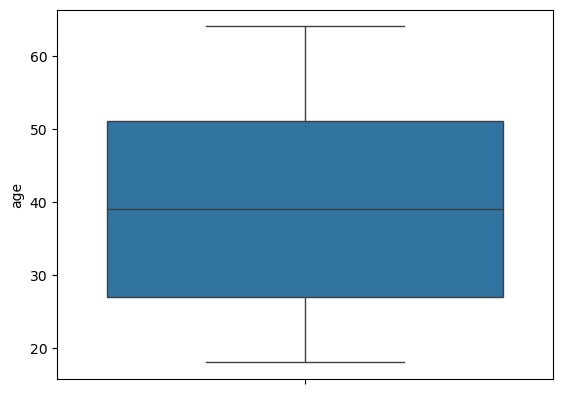

In [66]:

sns.boxplot(df['age'])

<Axes: ylabel='children'>

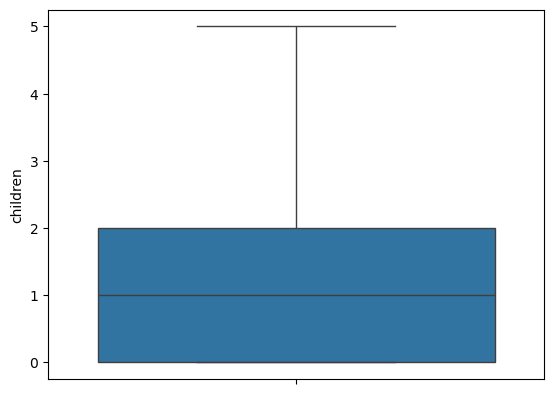

In [67]:
sns.boxplot(df['children'])

<Axes: ylabel='charges'>

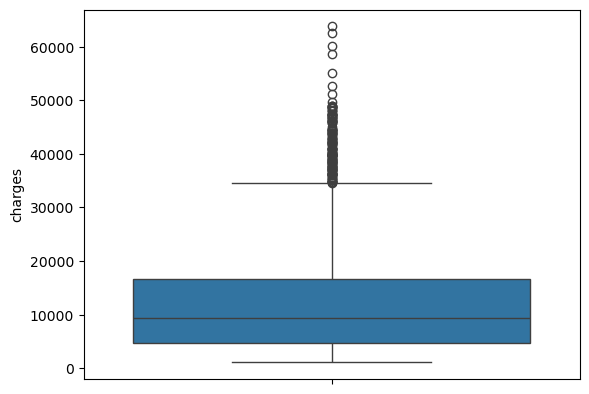

In [68]:
sns.boxplot(df['charges'])

C:\Users\shrey\AppData\Local\Temp\ipykernel_9184\4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

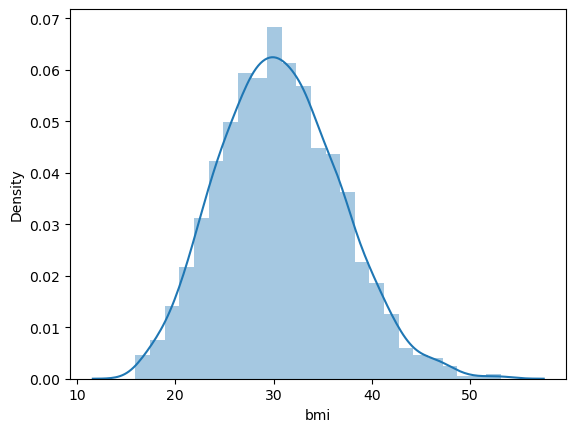

In [69]:
sns.distplot(df['bmi'])

In [70]:
# Q1 = df['bmi'].quantile(0.25)
# Q3 = df['bmi'].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# df['bmi'] = df['bmi'].clip(lower=lower, upper=upper)

C:\Users\shrey\AppData\Local\Temp\ipykernel_9184\249134749.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


<Axes: xlabel='charges', ylabel='Density'>

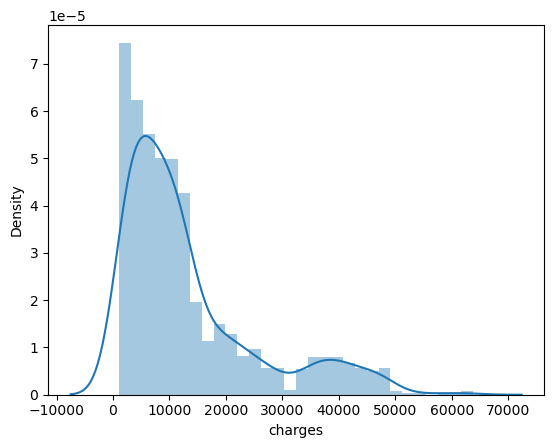

In [71]:
sns.distplot(df['charges'])


In [72]:
X=df.drop(columns=["charges"])

In [73]:
Y=df['charges']

In [74]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [75]:
Y


0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [77]:
X_train

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


In [78]:
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'no':0, 'yes':1})
df['region'] = df['region'].map({
    'southwest':0,
    'southeast':1,
    'northwest':2,
    'northeast':3
})



In [79]:
# Reload fresh dataset
df = pd.read_csv("insurance.csv")

# Encode
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df['region'] = df['region'].map({
    'southwest': 0,
    'southeast': 1,
    'northwest': 2,
    'northeast': 3
})

# Create X and y again
X = df.drop("charges", axis=1)
y = df["charges"]

# Split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

[1 0]
[1 0]
[0 1 2 3]


In [81]:
X_train

,age,sex,bmi,children,smoker,region
560,46,1,19.950,2,0,2
1285,47,1,24.320,0,0,3
1142,52,1,24.860,0,0,1
969,39,1,34.320,5,0,1
486,54,1,21.470,3,0,2
...,...,...,...,...,...,...
1095,18,1,31.350,4,0,3
1130,39,1,23.870,5,0,1
1294,58,0,25.175,0,0,3
860,37,1,47.600,2,1,0


In [82]:
X_test

,age,sex,bmi,children,smoker,region
764,45,1,25.175,2,0,3
887,36,1,30.020,0,0,2
890,64,1,26.885,0,1,2
1293,46,0,25.745,3,0,2
259,19,0,31.920,0,1,2
...,...,...,...,...,...,...
109,63,0,35.090,0,1,1
575,58,1,27.170,0,0,2
535,38,0,28.025,1,0,3
543,54,1,47.410,0,1,1


In [83]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [84]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model):
    pred = model.predict(X_test)

    print("R² Score :", round(r2_score(y_test, pred), 4))
    print("MAE      :", round(mean_absolute_error(y_test, pred), 2))
    print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, pred)), 2))

In [85]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
evaluate(lr)

R² Score : 0.7833
MAE      : 4186.51
RMSE     : 5799.59


In [86]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

evaluate(ridge)

R² Score : 0.7833
MAE      : 4187.97
RMSE     : 5800.16


In [87]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

evaluate(lasso)

R² Score : 0.7833
MAE      : 4186.52
RMSE     : 5799.61


In [88]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate(rf)

R² Score : 0.8661
MAE      : 2490.73
RMSE     : 4558.61


In [89]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train, y_train)

evaluate(gbr)

R² Score : 0.8747
MAE      : 2443.69
RMSE     : 4411.22


In [90]:
!pip install xgboost

In [91]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate(xgb)

R² Score : 0.8706
MAE      : 2452.79
RMSE     : 4481.29


In [92]:
!pip install catboost

In [93]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

evaluate(cat)

R² Score : 0.8756
MAE      : 2449.48
RMSE     : 4394.82


In [94]:
from sklearn.model_selection import cross_val_score

X = df.drop('charges', axis=1)
Y = df['charges']

cross_val_score(cat, X, Y, cv=12)

array([0.90636648, 0.81777431, 0.88635539, 0.77150305, 0.75179695,
       0.86307036, 0.91862188, 0.91300273, 0.79760079, 0.83073304,
       0.81720266, 0.88469571])

In [95]:
scores = cross_val_score(cat, X, Y, cv=12)

print("Scores:", scores)
print("Mean R²:", scores.mean())
print("Std Dev:", scores.std())

Scores: [0.90636648 0.81777431 0.88635539 0.77150305 0.75179695 0.86307036
 0.91862188 0.91300273 0.79760079 0.83073304 0.81720266 0.88469571]
Mean R²: 0.8465602784899403
Std Dev: 0.0543495718371656


In [96]:
import pickle

with open("medical_model111.pkl", "wb") as file:
    pickle.dump(cat, file)

In [97]:
with open("scaler_medical.pkl", "wb") as file:
    pickle.dump(sc, file)

In [98]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import scipy
import pickle

print("NumPy        :", np.__version__)
print("Pandas       :", pd.__version__)
print("Matplotlib   :", matplotlib.__version__)
print("Seaborn      :", sns.__version__)
print("Scikit-learn :", sklearn.__version__)
print("SciPy        :", scipy.__version__)

NumPy        : 2.3.5
Pandas       : 2.3.3
Matplotlib   : 3.10.6
Seaborn      : 0.13.2
Scikit-learn : 1.7.2
SciPy        : 1.16.3


In [99]:
import catboost
import xgboost

print("CatBoost     :", catboost.__version__)
print("XGBoost      :", xgboost.__version__)

CatBoost     : 1.2.10
XGBoost      : 3.3.0
